Let's load our saved data first, fresh, to confirm Notebook 2 is self-contained:

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
rfm = pd.read_csv(r'../Data/rfm.csv')
feature_scaled_df = pd.read_csv(r'../Data/feature_scaled_df.csv', index_col='Customer ID')

Let's verify everything is intact

In [4]:
print(rfm.shape)
print(feature_scaled_df.shape)

(5878, 6)
(5878, 3)


Okay, everything is as it is.

## Principal component Analysis (PCA)

In [5]:
from sklearn.decomposition import PCA

In [6]:
pca = PCA(n_components=2)

In [9]:
pca_result = pca.fit_transform(feature_scaled_df)

Let's check how much veriance our model PCA components capture:

In [14]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.74725232 0.20325631]
0.9505086343884523


`[0.74725232, 0.20325631]` — PC1 captures 74.7% of the variance, PC2 captures 20.3%. Two numbers because we asked for `n_components=2`.

`.sum()` — just adding those two numbers together: `0.747 + 0.203 = 0.9505`. This tells us the combined amount of information your 2D projection retains out of the original 3 features. 95.05% retained means only ~5% of the original variance was "lost" by compressing from 3 dimensions down to 2,meaning almost nothing meaningful is lost.

**Next:** Let's visualize it:

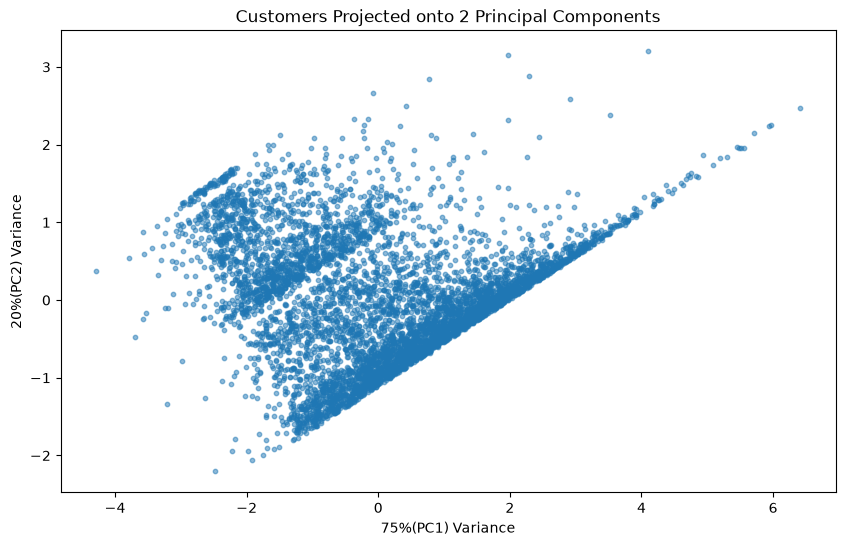

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, s=10)
plt.xlabel('75%(PC1) Variance')
plt.ylabel('20%(PC2) Variance')
plt.title('Customers Projected onto 2 Principal Components')
plt.show()

**What the shape tells us:**

* No clean, separated blobs. This is one continuous, dense cloud that thins out as it spreads — not 3-4 visually distinct islands with empty space  between them. That's an honest, important finding: our customer base doesn't naturally split into obviously separate groups. Customer behavior here is more of a spectrum (gradually more engaged → gradually less engaged) than distinct categories.

* The triangular/fan shape, densest near the bottom-left, thinning as it goes up and right. Most customers cluster tightly in the lower-left (low PC1, low-to-mid PC2) — this is our "typical" customer mass. As we move up and to the right, points get sparser — these are increasingly extreme/unusual customers.

* The scattered outlier points far to the right (PC1 ≈ 4-6.5) and the ones near the top (PC2 ≈ 2.5-3.2). These are very likely our wholesale-pattern customers from earlier — remember our CustomerID 16446, 18102, 14646? High Monetary/Frequency pulls them far from the main cloud along these axes. we're seeing the exact outlier behavior we investigated earlier, now visually confirmed.

**Why this matters for what comes next:**

Given there's no obvious visual separation into clean groups, don't expect K-Means to find some clean, obvious answer that jumps out at us either. The **elbow method** and **silhouette score** will likely show a soft signal, not a dramatic one. 

This is also exactly the kind of shape where DBSCAN's behavior will look meaningfully different from K-Means: DBSCAN, being density-based, may treat that dense lower-left mass as one or two clusters and correctly flag the sparse scattered points on the right/top as noise — while K-Means, forced to partition everything into exactly k groups regardless of density, will carve arbitrary boundaries through this continuous cloud, potentially even splitting the dense mass into artificial sub-groups just to satisfy k.